In [1]:
import pandas as pd
from prophet import Prophet
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data = pd.read_csv('/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/Type of analysis/Analisis temporal/merged files/csv/microsoft/microsoft_data.csv')

In [3]:
data

,Unnamed: 0,date,Price,revenue_musd,net_income_musd,total_assets_musd,total_liabilities_musd,share_holder_equity_musd,gdp_growth,interest_rate
0,0,2009-03-31,13.531229,13648.0,2977.0,68853.0,31910.0,36943.0,-3.23,0.15
1,1,2009-06-30,17.620026,13099.0,3045.0,77888.0,38330.0,39558.0,-3.98,0.16
2,2,2009-09-30,19.172707,12920.0,3574.0,81612.0,40400.0,41212.0,-3.13,0.12
3,3,2009-12-31,22.821438,19022.0,6662.0,82096.0,37813.0,44283.0,0.11,0.11
4,4,2010-03-31,22.032991,14503.0,4006.0,84910.0,39200.0,45710.0,1.75,0.20
...,...,...,...,...,...,...,...,...,...,...
61,61,2024-06-30,442.821350,64727.0,22036.0,512163.0,243686.0,268477.0,3.04,5.33
62,62,2024-09-30,427.093567,65585.0,24667.0,523013.0,235290.0,287723.0,2.72,4.83
63,63,2024-12-31,419.196533,69632.0,24108.0,533898.0,231203.0,302695.0,2.53,4.33
64,64,2025-03-31,374.087158,70066.0,25824.0,562624.0,240733.0,321891.0,1.99,4.33


In [4]:
# create column assets_liabilities_ratio
#data['assets_liabilities_ratio'] = data['total_assets_musd'] / data['total_liabilities_musd']

# drop unnecessary columns
data = data.drop(columns=['Unnamed: 0'])

In [5]:
#1)rename date to ds and Price to y for prophet

data = data.rename(columns={"date": "ds", "Price": "y"})

data["ds"]= pd.to_datetime(data["ds"], format="%Y-%m-%d")

#reorder columns
data = data[["ds", "y", "revenue_musd", "net_income_musd", "total_assets_musd","total_liabilities_musd", "share_holder_equity_musd", "gdp_growth", "interest_rate"]]

#create backtesting data

data_bt = data.iloc[:-4]

data[40:]

,ds,y,revenue_musd,net_income_musd,total_assets_musd,total_liabilities_musd,share_holder_equity_musd,gdp_growth,interest_rate
40,2019-03-31,111.028870,30571.0,8809.0,263281.0,168417.0,94864.0,1.93,2.42
41,2019-06-30,126.576942,33717.0,13187.0,286556.0,184226.0,102330.0,2.24,2.40
42,2019-09-30,131.804962,33055.0,10678.0,278955.0,172894.0,106061.0,2.80,1.83
43,2019-12-31,150.013428,36906.0,11649.0,282794.0,172685.0,110109.0,3.35,1.55
44,2020-03-31,150.432755,35021.0,10752.0,285449.0,170948.0,114501.0,1.28,0.05
45,2020-06-30,194.660019,38033.0,11202.0,301311.0,183007.0,118304.0,-7.50,0.09
46,2020-09-30,201.669800,37154.0,13893.0,301001.0,177609.0,123392.0,-1.41,0.09
47,2020-12-31,213.820297,43076.0,15463.0,304137.0,173901.0,130236.0,-1.02,0.09
48,2021-03-31,227.176147,41706.0,15457.0,308879.0,174374.0,134505.0,1.76,0.07
49,2021-06-30,261.628357,46152.0,16458.0,333779.0,191791.0,141988.0,12.24,0.10


In [6]:
#2) Add a future base scenario so Proheet can make predictions

# ================== CONFIG ==================
FUTURE_PERIODS = 6    # nº de trimestres a predecir
FREQ = "Q"            # frecuencia trimestral
REG_COLS = ["revenue_musd", "net_income_musd", "total_assets_musd","total_liabilities_musd",  "share_holder_equity_musd", "gdp_growth", "interest_rate"]
# ================== PREP ====================
df = data.copy()
#df = df.rename(columns={"DS": "ds"})   # Prophet requiere columnas: ds (datetime), y (target)
df["ds"] = pd.to_datetime(df["ds"], errors="coerce")

# Asegura que los regresores existan (si falta alguno, lo creamos como NaN)
for c in REG_COLS:
    if c not in df.columns:
        df[c] = np.nan

# Convierte gdp_growth a numérico si venía como texto/%
if df["gdp_growth"].dtype == "object":
    df["gdp_growth"] = (
        df["gdp_growth"].astype(str).str.replace("%", "", regex=False).str.replace(",", "", regex=False)
        .replace({"": np.nan}).astype(float)
    )

# Rellena huecos internos con forward-fill (opcional pero útil para entrenar)
df[REG_COLS] = df[REG_COLS].ffill()

# ================== ESCENARIO FUTURO ==================
# Calcula crecimiento medio trimestral para flows/equity
growth_rates = {}
n = len(df)

# exponential weights: more recent quarters get larger weight
K=8
weights = np.exp(np.linspace(8, 0, n))  
weights /= weights.sum()  # normalize to sum to 1

for col in ["revenue_musd", "net_income_musd", "total_assets_musd","total_liabilities_musd", "share_holder_equity_musd"]:
    gr = df[col].pct_change()
    growth_rates[col] = np.average(gr.dropna(), weights=weights[1:])  # skip first NaN


# Último punto observado
last = df.sort_values("ds").iloc[-1]

# Fechas futuras
future_dates = pd.date_range(start=df["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]
future = pd.DataFrame({"ds": future_dates})

# Proyecta regresores (escenario baseline)
for col in ["revenue_musd", "net_income_musd", "total_assets_musd","total_liabilities_musd", "share_holder_equity_musd"]:
    gr = 0.0 if np.isnan(growth_rates[col]) else growth_rates[col]
    future[col] = [last[col] * (1 + gr) ** i for i in range(1, FUTURE_PERIODS+1)]

# Mantén constantes estos regresores (o pon tu propio escenario)
#future["assets_liabilities_ratio"] = last["assets_liabilities_ratio"]
# gdp_growth: mantener último valor (o define tu propio escenario macro)
future["gdp_growth"] = last["gdp_growth"]
# interest_rate: mantener último valor (o define tu propio escenario macro)
future["interest_rate"] = last["interest_rate"]

# Combina histórico (con y) y futuro (sin y)
hist = df[["ds", "y"] + REG_COLS].copy()
future_full = pd.concat([hist, future], ignore_index=True)


/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_6992/4241952268.py:46: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_dates = pd.date_range(start=df["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]


In [7]:
#2) Replicate the same for backtesting data

# ================== PREP ====================
df_bt = data_bt.copy()
#df = df.rename(columns={"DS": "ds"})   # Prophet requiere columnas: ds (datetime), y (target)
df_bt["ds"] = pd.to_datetime(df_bt["ds"], errors="coerce")

# Asegura que los regresores existan (si falta alguno, lo creamos como NaN)
for c in REG_COLS:
    if c not in df.columns:
        df_bt[c] = np.nan

# Convierte gdp_growth a numérico si venía como texto/%
if df_bt["gdp_growth"].dtype == "object":
    df_bt["gdp_growth"] = (
        df_bt["gdp_growth"].astype(str).str.replace("%", "", regex=False).str.replace(",", "", regex=False)
        .replace({"": np.nan}).astype(float)
    )

# Rellena huecos internos con forward-fill (opcional pero útil para entrenar)
df_bt[REG_COLS] = df_bt[REG_COLS].ffill()

# ================== ESCENARIO FUTURO ==================
# Calcula crecimiento medio trimestral para flows/equity
growth_rates_bt = {}
n_bt = len(df_bt)

# exponential weights: more recent quarters get larger weight
K=()
weights_bt = np.exp(np.linspace(8, 0, n_bt))  
weights_bt /= weights_bt.sum()  # normalize to sum to 1

for col in ["revenue_musd", "net_income_musd", "total_assets_musd","total_liabilities_musd", "share_holder_equity_musd"]:
    gr_bt = df_bt[col].pct_change()
    growth_rates_bt[col] = np.average(gr_bt.dropna(), weights=weights_bt[1:])  # skip first NaN

# Último punto observado
last_bt = df_bt.sort_values("ds").iloc[-1]

# Fechas futuras
future_dates_bt = pd.date_range(start=df_bt["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]
future_bt = pd.DataFrame({"ds": future_dates_bt})

# Proyecta regresores (escenario baseline)
for col in ["revenue_musd", "net_income_musd", "total_assets_musd","total_liabilities_musd", "share_holder_equity_musd"]:
    gr_bt = 0.0 if np.isnan(growth_rates_bt[col]) else growth_rates_bt[col]
    future_bt[col] = [last_bt[col] * (1 + gr_bt) ** i for i in range(1, FUTURE_PERIODS+1)]

# gdp_growth: mantener último valor (o define tu propio escenario macro)
future_bt["gdp_growth"] = last_bt["gdp_growth"]
# interest_rate: mantener último valor (o define tu propio escenario macro)
future_bt["interest_rate"] = last_bt["interest_rate"]

# Combina histórico (con y) y futuro (sin y)
hist_bt = df_bt[["ds", "y"] + REG_COLS].copy()
future_full_bt = pd.concat([hist_bt, future_bt], ignore_index=True)

/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_6992/293703122.py:41: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_dates_bt = pd.date_range(start=df_bt["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]


In [8]:
growth_rates_bt

{'revenue_musd': np.float64(0.04289040001089713),
 'net_income_musd': np.float64(-0.1729605949653219),
 'total_assets_musd': np.float64(0.047402092947257994),
 'total_liabilities_musd': np.float64(0.05187451623445665),
 'share_holder_equity_musd': np.float64(0.04440741789931807)}

In [9]:
#3) Initializa model and an train it

m=Prophet()

for col in REG_COLS:
    m.add_regressor(col)

#4) Fit and train with only historical data (with y)
train_df = future_full.dropna(subset=["y"]).copy()
m.fit(train_df)
                       

#5) Make predictions for the full dataset (historical + future)
predict_df = future_full[["ds"] + REG_COLS].copy()
forecast = m.predict(predict_df)

#6) Plot the results. Merge forecast with original data to compare
out = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].merge(
    df[["ds","y"]], on="ds", how="left"
).sort_values("ds")

print(out.tail(12))



20:29:26 - cmdstanpy - INFO - Chain [1] start processing
20:29:27 - cmdstanpy - INFO - Chain [1] done processing


           ds        yhat  yhat_lower  yhat_upper           y
60 2024-03-31  382.162120  357.872649  406.365593  416.083160
61 2024-06-30  401.294001  378.041530  427.135030  442.821350
62 2024-09-30  423.355323  398.034280  445.313501  427.093567
63 2024-12-31  410.339376  386.939203  434.215776  419.196533
64 2025-03-31  440.084709  416.230087  463.147637  374.087158
65 2025-06-30  502.701204  478.228875  526.775106  496.593658
66 2025-09-30  551.748036  528.145462  576.129631         NaN
67 2025-12-31  541.605001  518.548238  565.572022         NaN
68 2026-03-31  608.157234  583.665849  632.628998         NaN
69 2026-06-30  631.013282  607.395318  655.058779         NaN
70 2026-09-30  683.269602  659.296869  706.146665         NaN
71 2026-12-31  692.065125  666.909754  716.516937         NaN


In [10]:
#3) Replicate the same for backtesting data

m_bt=Prophet()

for col in REG_COLS:
    m_bt.add_regressor(col)

#4) Fit and train with only historical data (with y)
train_df_bt = future_full_bt.dropna(subset=["y"]).copy()
m_bt.fit(train_df_bt)
                       

#5) Make predictions for the full dataset (historical + future)
predict_df_bt = future_full_bt[["ds"] + REG_COLS].copy()
forecast_bt = m_bt.predict(predict_df_bt)

#6) Plot the results. Merge forecast with original data to compare
out_bt = forecast_bt[["ds", "yhat", "yhat_lower", "yhat_upper"]].merge(
    df_bt[["ds","y"]], on="ds", how="left"
).sort_values("ds")

print(out_bt.tail(12))

20:29:27 - cmdstanpy - INFO - Chain [1] start processing
20:29:27 - cmdstanpy - INFO - Chain [1] done processing


           ds        yhat  yhat_lower  yhat_upper           y
56 2023-03-31  274.446323  256.047943  293.425841  282.801575
57 2023-06-30  308.067808  288.618574  327.413777  334.775482
58 2023-09-30  331.292951  312.295433  350.154674  311.062347
59 2023-12-31  376.281185  356.428456  396.143874  371.209137
60 2024-03-31  407.785630  389.466980  427.153869  416.083160
61 2024-06-30  432.391621  413.074960  451.391458  442.821350
62 2024-09-30  489.460103  471.341792  507.939202         NaN
63 2024-12-31  485.990587  465.552650  506.066454         NaN
64 2025-03-31  557.999886  539.589584  577.839767         NaN
65 2025-06-30  580.204338  561.238589  599.654361         NaN
66 2025-09-30  643.820659  625.306554  662.630724         NaN
67 2025-12-31  659.085042  639.787895  677.592017         NaN


In [11]:
#4) Merge prediction with actual y

# Keep all rows (historical + future)
results = forecast[["ds","yhat","yhat_lower","yhat_upper"]].merge(
    data.rename(columns={"DS":"ds"})[["ds","y"]],
    on="ds", how="left"
)

# Flag which rows are future
results["is_future"] = results["y"].isna()

# Compute metrics only on historical rows
mask = ~results["is_future"]
mae = mean_absolute_error(results.loc[mask,"y"], results.loc[mask,"yhat"])
rmse = mean_squared_error(results.loc[mask,"y"], results.loc[mask,"yhat"])
r2   = r2_score(results.loc[mask,"y"], results.loc[mask,"yhat"])

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

# Show last 12 rows (will include future with y = NaN)
print(results.tail(12))

MAE: 13.259009554875288
RMSE: 349.4722569756593
R²: 0.9810173916415591
           ds        yhat  yhat_lower  yhat_upper           y  is_future
60 2024-03-31  382.162120  357.872649  406.365593  416.083160      False
61 2024-06-30  401.294001  378.041530  427.135030  442.821350      False
62 2024-09-30  423.355323  398.034280  445.313501  427.093567      False
63 2024-12-31  410.339376  386.939203  434.215776  419.196533      False
64 2025-03-31  440.084709  416.230087  463.147637  374.087158      False
65 2025-06-30  502.701204  478.228875  526.775106  496.593658      False
66 2025-09-30  551.748036  528.145462  576.129631         NaN       True
67 2025-12-31  541.605001  518.548238  565.572022         NaN       True
68 2026-03-31  608.157234  583.665849  632.628998         NaN       True
69 2026-06-30  631.013282  607.395318  655.058779         NaN       True
70 2026-09-30  683.269602  659.296869  706.146665         NaN       True
71 2026-12-31  692.065125  666.909754  716.516937    

In [12]:
#4) Replicate the same for backtesting data

# Keep all rows (historical + future)
results_bt = forecast_bt[["ds","yhat","yhat_lower","yhat_upper"]].merge(
    data_bt.rename(columns={"DS":"ds"})[["ds","y"]],
    on="ds", how="left"
)

# Flag which rows are future
results_bt["is_future"] = results_bt["y"].isna()

# Compute metrics only on historical rows
mask_bt = ~results_bt["is_future"]
mae_bt = mean_absolute_error(results_bt.loc[mask_bt,"y"], results_bt.loc[mask_bt,"yhat"])
rmse_bt = mean_squared_error(results_bt.loc[mask_bt,"y"], results_bt.loc[mask_bt,"yhat"])
r2_bt   = r2_score(results_bt.loc[mask_bt,"y"], results_bt.loc[mask_bt,"yhat"])

print("MAE:", mae_bt)
print("RMSE:", rmse_bt)
print("R²:", r2_bt)

# Show last 12 rows (will include future with y = NaN)
print(results_bt.tail(12))

MAE: 11.710937303121712
RMSE: 219.62279133756257
R²: 0.9837213547780264
           ds        yhat  yhat_lower  yhat_upper           y  is_future
56 2023-03-31  274.446323  256.047943  293.425841  282.801575      False
57 2023-06-30  308.067808  288.618574  327.413777  334.775482      False
58 2023-09-30  331.292951  312.295433  350.154674  311.062347      False
59 2023-12-31  376.281185  356.428456  396.143874  371.209137      False
60 2024-03-31  407.785630  389.466980  427.153869  416.083160      False
61 2024-06-30  432.391621  413.074960  451.391458  442.821350      False
62 2024-09-30  489.460103  471.341792  507.939202         NaN       True
63 2024-12-31  485.990587  465.552650  506.066454         NaN       True
64 2025-03-31  557.999886  539.589584  577.839767         NaN       True
65 2025-06-30  580.204338  561.238589  599.654361         NaN       True
66 2025-09-30  643.820659  625.306554  662.630724         NaN       True
67 2025-12-31  659.085042  639.787895  677.592017   

In [13]:
#5) Compare the actuall y with the yhat prediction for the backtesting period
comparison = data[["ds", "y"]]
comparison_bt = results_bt[["ds", "yhat"]]
comparison = comparison.merge(comparison_bt, on="ds", how="inner")
comparison["absolute error"] = (comparison["y"] - comparison["yhat"]).abs()
comparison["relative error"] = ((comparison["absolute error"] / comparison["y"])*100).round(1).astype(str)+"%"
print(comparison.tail(12))

           ds           y        yhat  absolute error relative error
54 2022-09-30  227.246918  260.462762       33.215844          14.6%
55 2022-12-31  234.658417  241.733430        7.075014           3.0%
56 2023-03-31  282.801575  274.446323        8.355251           3.0%
57 2023-06-30  334.775482  308.067808       26.707674           8.0%
58 2023-09-30  311.062347  331.292951       20.230603           6.5%
59 2023-12-31  371.209137  376.281185        5.072049           1.4%
60 2024-03-31  416.083160  407.785630        8.297530           2.0%
61 2024-06-30  442.821350  432.391621       10.429729           2.4%
62 2024-09-30  427.093567  489.460103       62.366536          14.6%
63 2024-12-31  419.196533  485.990587       66.794054          15.9%
64 2025-03-31  374.087158  557.999886      183.912728          49.2%
65 2025-06-30  496.593658  580.204338       83.610680          16.8%


/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_6992/3947255231.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figl.show()


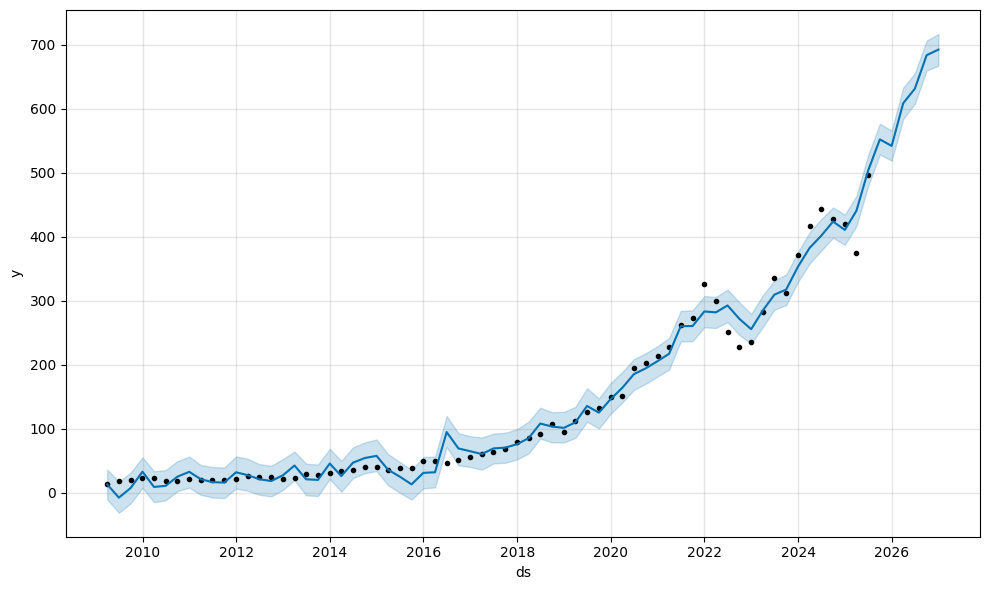

In [14]:
#5) Plot the results

figl = m.plot(forecast)
figl.show()

In [15]:
correlations = data.corr()
correlations

,ds,y,revenue_musd,net_income_musd,total_assets_musd,total_liabilities_musd,share_holder_equity_musd,gdp_growth,interest_rate
ds,1.000000,0.900988,0.931315,0.842774,0.960501,0.973850,0.862584,0.268059,0.734807
y,0.900988,1.000000,0.982372,0.938972,0.959119,0.870790,0.956634,0.209424,0.773279
revenue_musd,0.931315,0.982372,1.000000,0.935603,0.977804,0.894503,0.968944,0.232185,0.802555
net_income_musd,0.842774,0.938972,0.935603,1.000000,0.896381,0.797745,0.909135,0.198542,0.732138
total_assets_musd,0.960501,0.959119,0.977804,0.896381,1.000000,0.950964,0.957049,0.226848,0.818976
total_liabilities_musd,0.973850,0.870790,0.894503,0.797745,0.950964,1.000000,0.820444,0.232517,0.742348
share_holder_equity_musd,0.862584,0.956634,0.968944,0.909135,0.957049,0.820444,1.000000,0.201364,0.817985
gdp_growth,0.268059,0.209424,0.232185,0.198542,0.226848,0.232517,0.201364,1.000000,0.138662
interest_rate,0.734807,0.773279,0.802555,0.732138,0.818976,0.742348,0.817985,0.138662,1.000000


/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_6992/89357559.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figl_bt.show()


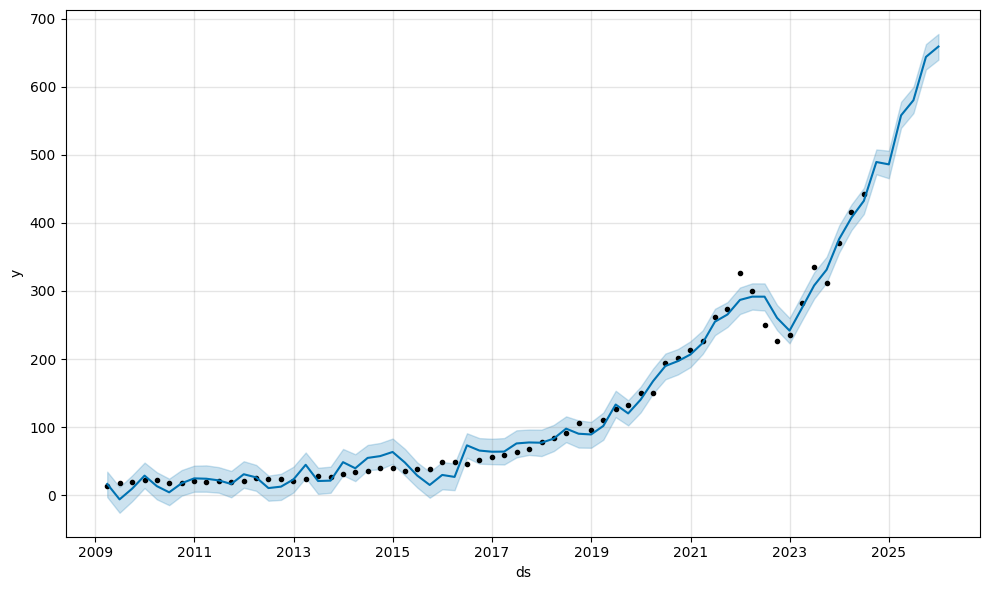

In [16]:
# 5) Plot the results for backtesting data

figl_bt = m_bt.plot(forecast_bt)
figl_bt.show()

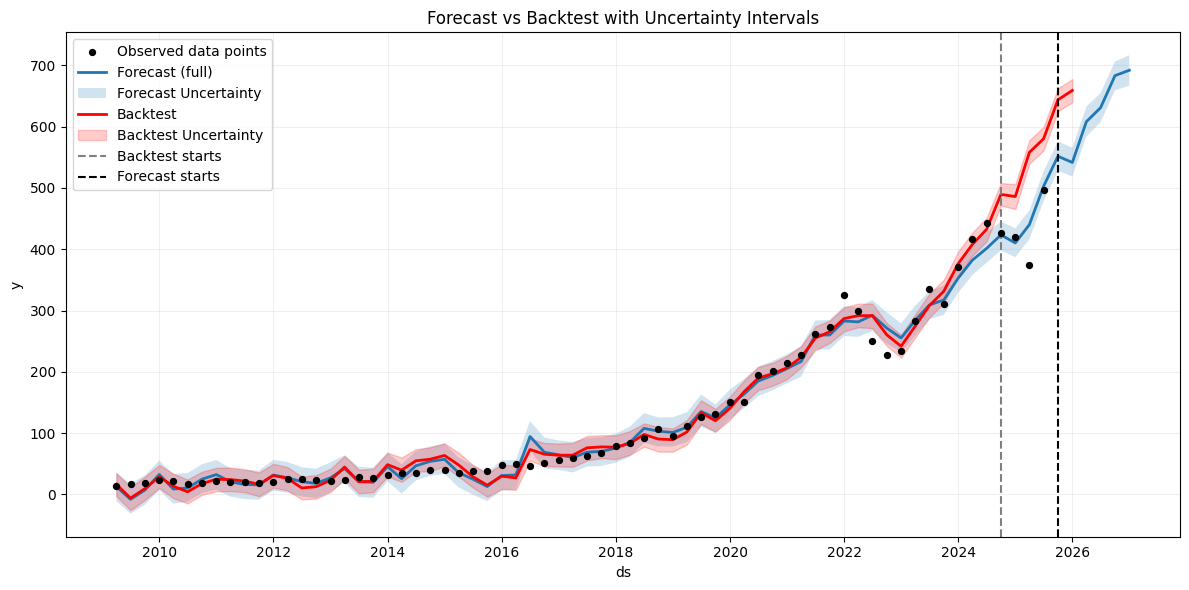

In [17]:
#6) Plot the results together

# --- Ensure datetime dtype
results['ds'] = pd.to_datetime(results['ds'])
results_bt['ds'] = pd.to_datetime(results_bt['ds'])

# --- Find split dates
bt_split   = results_bt.loc[results_bt['is_future'], 'ds'].min()   # ~2024-09-30
full_split = results.loc[results['is_future'], 'ds'].min()         # ~2025-09-30

fig, ax = plt.subplots(figsize=(12,6))

# Actuals (dots) from full dataset
mask_actual = ~results['is_future']
ax.scatter(results.loc[mask_actual, 'ds'],
           results.loc[mask_actual, 'y'],
           s=18, label='Observed data points', zorder=3, color='k')

# Forecast (full) line + CI
ax.plot(results['ds'], results['yhat'], label='Forecast (full)', linewidth=2)
ax.fill_between(results['ds'], results['yhat_lower'], results['yhat_upper'],
                alpha=0.2, label='Forecast Uncertainty')

# Backtest line + CI
ax.plot(results_bt['ds'], results_bt['yhat'], label='Backtest', linewidth=2, color='red')
ax.fill_between(results_bt['ds'], results_bt['yhat_lower'], results_bt['yhat_upper'],
                alpha=0.2, label='Backtest Uncertainty', color='red')

# --- Vertical split lines
if pd.notna(bt_split):
    ax.axvline(bt_split, linestyle='--', linewidth=1.5, color='gray')
    # Dummy handle just for legend
    ax.plot([], [], linestyle='--', linewidth=1.5, color='gray', label='Backtest starts')

if pd.notna(full_split):
    ax.axvline(full_split, linestyle='--', linewidth=1.5, color='black')
    # Dummy handle just for legend
    ax.plot([], [], linestyle='--', linewidth=1.5, color='black', label='Forecast starts')

# Cosmetics
ax.set_title('Forecast vs Backtest with Uncertainty Intervals')
ax.set_xlabel('ds'); ax.set_ylabel('y')
# Deduplicate legend labels
handles, labels = ax.get_legend_handles_labels()
uniq = dict(zip(labels, handles))
ax.legend(uniq.values(), uniq.keys(), loc='upper left')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()